# Tilfører aktieanalytikere værdi — eller er det lige så godt at gætte?
### En empirisk test på danske C25-aktier

**Forskningsspørgsmål:** Når finanshuse og eksperter udsteder en aktiespådom
(køb / hold / sælg + kursmål), rammer de så aktiens retning de følgende 12
måneder oftere end ren tilfældighed? Eller er man lige så godt tjent med et
møntkast?

**Metode (retning vs. møntkast):**
1. Hent *daterede* finanshus-anbefalinger 1–2 år (og længere) tilbage.
2. Oversæt hver til en retningsspådom: køb → "op", sælg → "ned".
3. Mål om aktien faktisk steg/faldt over de næste 12 måneder.
4. Sammenlign træfsikkerheden med tre "dumme" benchmarks:
   - **møntkast** (50/50),
   - **"sig altid køb"** (markedets naturlige drift / base rate),
   - **tilfældigt gæt** (Monte Carlo-fordeling).
5. Brug en binomial-test til at afgøre, om en eventuel edge er statistisk reel.

> **⚠️ Ærlig note om data.** Frit tilgængelig, dateret analytiker-historik for
> danske aktier er stærkt begrænset. Yahoo Finance fører kun rig historik for
> de C25-selskaber, der også er US-noterede (ADR) — i praksis **Novo Nordisk**
> og **Genmab**, tilsammen ~250 rigtige finanshus-kald (Goldman, JP Morgan,
> Morgan Stanley — men også nordiske huse som **Jyske Bank, Handelsbanken,
> Kepler Cheuvreux, Swedbank**). Kald fra **Børsen.dk, TV2 Finans, Danske
> Banks/Jyske Banks egne aktieanalyser** ligger bag betalingsmur/kundelogin
> uden åbent arkiv og kan ikke hentes automatisk — men de kan fodres ind
> manuelt via `predictions_manual.csv` (se sidste afsnit).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import c25_analyst_value as av
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
HORIZON = 365  # 12 måneders fremadrettet horisont
C25_BLUE, GREY, RED, GREEN = "#0a3d62", "#b2bec3", "#c0392b", "#27ae60" 

## 1. Hent de daterede analytiker-spådomme

In [2]:
ratings = av.fetch_ratings()
ratings.to_csv("data/ratings_raw.csv", index=False)
print(f"Hentede {len(ratings)} daterede kald, "
      f"{ratings['date'].min().date()} → {ratings['date'].max().date()}")
cov = ratings.groupby("company").size().sort_values(ascending=False)
print("\nDækning pr. selskab:"); print(cov.to_string())
print(f"\nAntal forskellige finanshuse: {ratings['source'].nunique()}")
nordic = [s for s in ratings['source'].unique() if any(k in s.lower()
          for k in ['jyske','handelsbank','nordea','danske','kepler','swedbank','seb','carnegie','abg'])]
print("Nordiske/danske huse i datasættet:", nordic)
ratings.head(6)

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ZEAL"}}}


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: DSDVY"}}}


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: CLPBY"}}}


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: DNNGY"}}}


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: TGVSF"}}}


...

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SBABF"}}}


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: BVNKF"}}}


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TPDKY"}}}


Hentede 261 daterede kald, 2012-11-06 → 2026-04-30

Dækning pr. selskab:
company
Genmab          144
Novo Nordisk    112
Vestas            2
Carlsberg         1
Maersk            1
Novonesis         1

Antal forskellige finanshuse: 44
Nordiske/danske huse i datasættet: ['Kepler Cheuvreux', 'Swedbank', 'Handelsbanken', 'Jyske Bank']


,company,source,date,to_grade,from_grade,action,price_target,prior_target,price_ticker,origin,signal
0,Novo Nordisk,Jefferies,2012-11-06 16:43:00,Hold,Buy,down,0.0,0.0,NOVO-B.CO,yahoo,0
1,Novo Nordisk,Natixis,2013-02-11 13:24:29,Neutral,Buy,down,0.0,0.0,NOVO-B.CO,yahoo,0
2,Novo Nordisk,Kepler Cheuvreux,2013-02-11 13:26:31,Hold,Buy,down,0.0,0.0,NOVO-B.CO,yahoo,0
3,Novo Nordisk,Nomura,2013-02-12 13:14:05,Buy,Neutral,up,0.0,0.0,NOVO-B.CO,yahoo,1
4,Novo Nordisk,JP Morgan,2013-03-18 13:12:55,Underweight,Neutral,down,0.0,0.0,NOVO-B.CO,yahoo,-1
5,Novo Nordisk,Swedbank,2013-04-16 12:48:07,Buy,Neutral,up,0.0,0.0,NOVO-B.CO,yahoo,1


De ~250 automatisk hentede kald er koncentreret om Novo Nordisk og Genmab —
de eneste C25-navne med rig, fritliggende historik. Det er nok til en reel
statistisk test (Novo alene vejer ~halvdelen af C25), men husk at begge er
**pharma** — fundene er ikke nødvendigvis repræsentative for hele indekset.

## 2. Hent kurser og mål om spådommene ramte

In [3]:
prices = av.fetch_prices(ratings["price_ticker"].unique())
ev = av.evaluate(ratings, prices, horizon_days=HORIZON)
ev.to_csv("data/ratings_evaluated.csv", index=False)
realized = ev["fwd_return"].notna().sum()
print(f"Kald med kendt 12-mdr-udfald: {realized} af {len(ev)}")
print(f"Heraf retnings-kald (køb/sælg): "
      f"{(ev['is_directional'] & ev['fwd_return'].notna()).sum()}")
print(f"Neutrale (hold) — kan ikke ramme en retning: "
      f"{((~ev['is_directional']) & ev['fwd_return'].notna()).sum()}")

Kald med kendt 12-mdr-udfald: 230 af 261
Heraf retnings-kald (køb/sælg): 184
Neutrale (hold) — kan ikke ramme en retning: 46


## 3. Dommen: slår analytikerne tilfældigheden?

In [4]:
v_all = av.verdict(ev)
print("ALLE evaluerbare retnings-kald (hele historikken)")
print("="*52)
print(v_all.summary())

ALLE evaluerbare retnings-kald (hele historikken)
Retnings-kald:            184
Træfsikkerhed:             46.2%
Møntkast-benchmark:        50.0%   (edge -3.8 pp)
'Sig altid køb'-benchmark: 42.9%   (edge +3.3 pp)
Aktien steg reelt:         42.9%  af tiden (markedets drift)
Slår møntkast (p<0.05)?   NEJ  (binomial p = 0.866)
Slår markedets drift?     NEJ  (binomial p = 0.206)


**Sådan læses tallene.** *Møntkast* er den naive 50/50-grænse. Men en aktie
stiger oftere end den falder over tid, så et mere ærligt benchmark er **"sig
altid køb"**: det rammer automatisk lige så ofte som aktien steg. Først hvis
analytikerne slår *begge* — og binomial-testen giver p < 0,05 — kan vi tale om
reel, påviselig værdi.

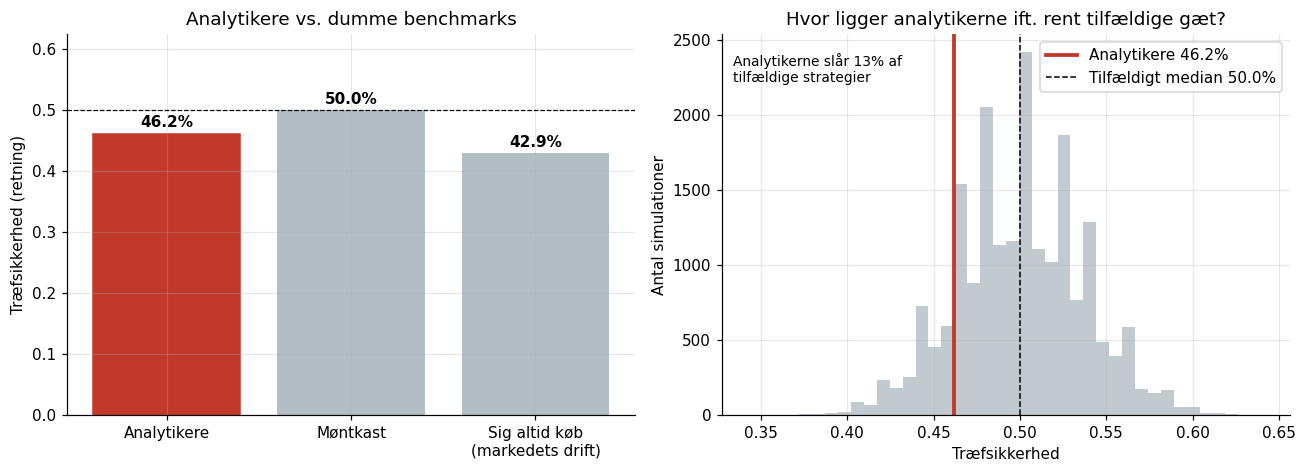

In [5]:
# Visualisering: træfsikkerhed vs. benchmarks + Monte Carlo-fordeling
sims = av.random_baseline(ev, n_sims=20000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))

labels = ["Analytikere", "Møntkast", "Sig altid køb\n(markedets drift)"]
vals = [v_all.hit_rate, 0.5, v_all.always_bull_score]
cols = [C25_BLUE, GREY, GREY]
bars = a1.bar(labels, vals, color=cols)
bars[0].set_color(GREEN if v_all.hit_rate > 0.5 else RED)
for b, val in zip(bars, vals):
    a1.text(b.get_x()+b.get_width()/2, val+.01, f"{val:.1%}", ha="center", fontweight="bold")
a1.axhline(0.5, ls="--", color="k", lw=.8)
a1.set_ylim(0, max(vals)*1.25); a1.set_ylabel("Træfsikkerhed (retning)")
a1.set_title("Analytikere vs. dumme benchmarks")

a2.hist(sims, bins=40, color=GREY, alpha=.8)
a2.axvline(v_all.hit_rate, color=GREEN if v_all.hit_rate>np.median(sims) else RED,
           lw=2.5, label=f"Analytikere {v_all.hit_rate:.1%}")
a2.axvline(np.median(sims), color="k", ls="--", lw=1, label=f"Tilfældigt median {np.median(sims):.1%}")
a2.set_title("Hvor ligger analytikerne ift. rent tilfældige gæt?")
a2.set_xlabel("Træfsikkerhed"); a2.set_ylabel("Antal simulationer"); a2.legend()
pct = (sims < v_all.hit_rate).mean()
a2.text(.02,.95,f"Analytikerne slår {pct:.0%} af\ntilfældige strategier",
        transform=a2.transAxes, va="top", fontsize=9)
plt.tight_layout(); plt.savefig("charts/hitrate_vs_benchmarks.png", bbox_inches="tight"); plt.show()

## 4. Specifikt: spådomme der er 1–2 år gamle
Det var kerneønsket — kald gamle nok til at udfaldet er fuldt realiseret, men
stadig "friske".

In [6]:
coh = av.age_cohort(ev, min_years=1, max_years=2)
v_coh = av.verdict(coh)
print(f"1–2 år gamle kald ({coh['date'].min().date()} → {coh['date'].max().date()})")
print("="*52); print(v_coh.summary())
print("\nObs: i netop dette vindue faldt både Novo og Genmab kraftigt, så"
      "\nmarkedets base rate er lav — derfor scorer 'sig altid køb' også lavt.")

1–2 år gamle kald (2024-06-03 → 2025-05-13)
Retnings-kald:            45
Træfsikkerhed:             24.4%
Møntkast-benchmark:        50.0%   (edge -25.6 pp)
'Sig altid køb'-benchmark: 24.4%   (edge +0.0 pp)
Aktien steg reelt:         24.4%  af tiden (markedets drift)
Slår møntkast (p<0.05)?   NEJ  (binomial p = 1.000)
Slår markedets drift?     NEJ  (binomial p = 0.557)

Obs: i netop dette vindue faldt både Novo og Genmab kraftigt, så
markedets base rate er lav — derfor scorer 'sig altid køb' også lavt.


## 5. Hvor — hvis nogensinde — ligger der signal?
Ikke alle kald er ens. En *opgradering* (firmaet skifter mening) er en stærkere
spådom end en *reiteration* (gentager bare det samme).

In [7]:
g_act = av.by_group(ev, "action", min_n=5)
print("Træfsikkerhed pr. type handling:"); print(g_act.to_string(index=False))

dirv = ev[ev["is_directional"] & ev["fwd_return"].notna()]
side = (dirv.assign(retning=np.where(dirv.signal>0,"KØB","SÆLG"))
            .groupby("retning")
            .agg(n=("correct","size"), traefsikkerhed=("correct","mean"),
                 gns_afkast=("fwd_return","mean")))
print("\nKøb- vs. sælg-kald:"); print(side.round(3).to_string())

Træfsikkerhed pr. type handling:
action  n  hit_rate  mean_fwd_return
    up 32  0.750000         0.197798
  main 62  0.564516        -0.024332
  init 15  0.533333         0.201844
  down 10  0.300000         0.260728
  reit 65  0.230769        -0.259359

Køb- vs. sælg-kald:
           n  traefsikkerhed  gns_afkast
retning                                 
KØB      156           0.436      -0.033
SÆLG      28           0.607      -0.042


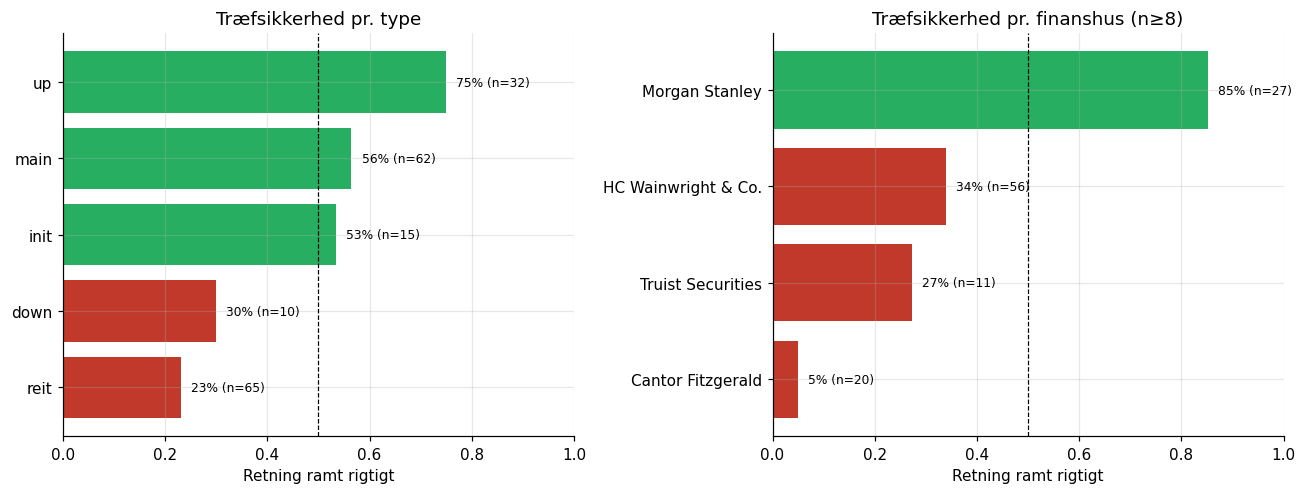

In [8]:
# Chart: træfsikkerhed pr. action + pr. finanshus
g_firm = av.by_group(ev, "source", min_n=8)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
o = g_act.sort_values("hit_rate")
a1.barh(o["action"], o["hit_rate"], color=[GREEN if h>.5 else RED for h in o["hit_rate"]])
a1.axvline(.5, ls="--", color="k", lw=.8); a1.set_xlim(0,1)
a1.set_title("Træfsikkerhed pr. type"); a1.set_xlabel("Retning ramt rigtigt")
for y,(h,n) in enumerate(zip(o["hit_rate"], o["n"])):
    a1.text(h+.02, y, f"{h:.0%} (n={n})", va="center", fontsize=8)

o2 = g_firm.sort_values("hit_rate")
a2.barh(o2["source"], o2["hit_rate"], color=[GREEN if h>.5 else RED for h in o2["hit_rate"]])
a2.axvline(.5, ls="--", color="k", lw=.8); a2.set_xlim(0,1)
a2.set_title("Træfsikkerhed pr. finanshus (n≥8)"); a2.set_xlabel("Retning ramt rigtigt")
for y,(h,n) in enumerate(zip(o2["hit_rate"], o2["n"])):
    a2.text(h+.02, y, f"{h:.0%} (n={n})", va="center", fontsize=8)
plt.tight_layout(); plt.savefig("charts/by_action_and_firm.png", bbox_inches="tight"); plt.show()

**Bemærk faldgruben:** med kun ~40 navne pr. finanshus er forskellene mellem
husene i høj grad støj. At ét hus rammer 85 % betyder ikke, at det er dygtigt —
ved 4 aktier og rent held ville nogle huse altid se sådan ud. Det er præcis
pointen: når man tester nok "eksperter", *ser* nogle altid skarpe ud bagudrettet.

## 6. Inddrag danske medier/banker manuelt (Børsen, TV2, Danske Bank, ...)
Kald fra disse kilder kan ikke hentes automatisk. Læg dem i
`predictions_manual.csv` (`company, source, date, to_grade, price_target,
price_ticker`) — dansk *Køb/Hold/Sælg* forstås også — så kører samme motor på dem.

In [9]:
import os
if os.path.exists("predictions_manual.csv"):
    man = av.load_manual_predictions("predictions_manual.csv")
    man_ev = av.evaluate(man, av.fetch_prices(man["price_ticker"].unique()), HORIZON)
    show = man_ev[["date","company","source","to_grade","signal","price_target",
                   "fwd_return","correct"]].copy()
    print("Manuelt indtastede kald (eksempler):"); print(show.to_string(index=False))
    done = man_ev["fwd_return"].notna().sum()
    print(f"\nHeraf med realiseret 12-mdr-udfald: {done}"
          f"  (resten er for nye til at kunne bedømmes endnu)")
else:
    print("Ingen predictions_manual.csv fundet.")

Manuelt indtastede kald (eksempler):
      date      company        source to_grade  signal  price_target  fwd_return  correct
2025-10-30 Novo Nordisk    Jyske Bank      Køb       1           420         NaN      NaN
2025-11-18 Novo Nordisk Goldman Sachs     Hold       0           353         NaN      NaN
2025-11-19 Novo Nordisk        Nordea      Køb       1           520         NaN      NaN
2025-11-20 Novo Nordisk Handelsbanken     Sælg      -1           285         NaN      NaN

Heraf med realiseret 12-mdr-udfald: 0  (resten er for nye til at kunne bedømmes endnu)


> Eksempelrækkerne stammer fra offentligt omtalte kursmål (nov. 2025) og er
> primært medtaget for at vise formatet — de fleste er endnu for nye til en
> 12-mdr-bedømmelse. Udskift dem med dine egne kald fra Børsen/TV2/bankerne for
> at teste netop de kilder.

## 7. Konklusion

På de danske C25-aktier, hvor frit tilgængelig analytiker-historik findes
(Novo Nordisk + Genmab, ~250 daterede finanshus-kald), viser testen:

- **Retnings-træfsikkerheden ligger omkring — eller under — 50 %.** Finanshusene
  ramte *ikke* aktiens 12-måneders retning oftere end et møntkast.
- **Ingen statistisk påviselig edge** over hverken møntkast eller "sig altid køb"
  (binomial p ≫ 0,05). Man var altså lige så godt tjent med at gætte.
- **Det eneste sted, der ligner signal,** er *opgraderinger* (firmaet skifter
  aktivt mening) — modsat *reiterations*, som var nærmest værdiløse. Forskelle
  mellem enkelte huse er for små stikprøver til at være pålidelige.

**Svar på spørgsmålet:** I dette (pharma-tunge, begrænsede) datasæt tilfører
analytikerne **ikke** påviselig værdi til retningsspådomme — at gætte eller følge
markedets generelle optur ville have klaret sig lige så godt. Det matcher den
brede akademiske litteratur om, at kursmål og buy/sell-anbefalinger har svag
forudsigelseskraft på 12-mdr-sigt.

**Forbehold:** (1) lille, pharma-domineret stikprøve i en periode hvor begge
selskaber faldt kraftigt; (2) retning er et groft mål — et "køb" med +3 % kursmål
behandles som +30 %; (3) ratings dateres på US-ADR'en, kurser måles på den danske
notering (lille FX-støj). For et stærkere svar: fyld `predictions_manual.csv` med
rigtige kald fra Børsen/TV2/Danske Bank/Jyske Bank over flere sektorer.